# Exploratory Data Analysis (EDA)
## INX Future Inc — Employee Performance
### Made by - **Chinmay Shastry**
**Goal:** Understand the data through visualizations before building any model.

## Step 1 — Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Raw for readable chart labels, processed for correlation
df     = pd.read_csv('../../data/raw/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1_8.csv')
df_num = pd.read_csv('../../data/processed/employee_performance_processed.csv')
print("Raw:", df.shape, "| Processed:", df_num.shape)

Raw: (1200, 28) | Processed: (1200, 58)


## Step 2 — Target Variable Distribution

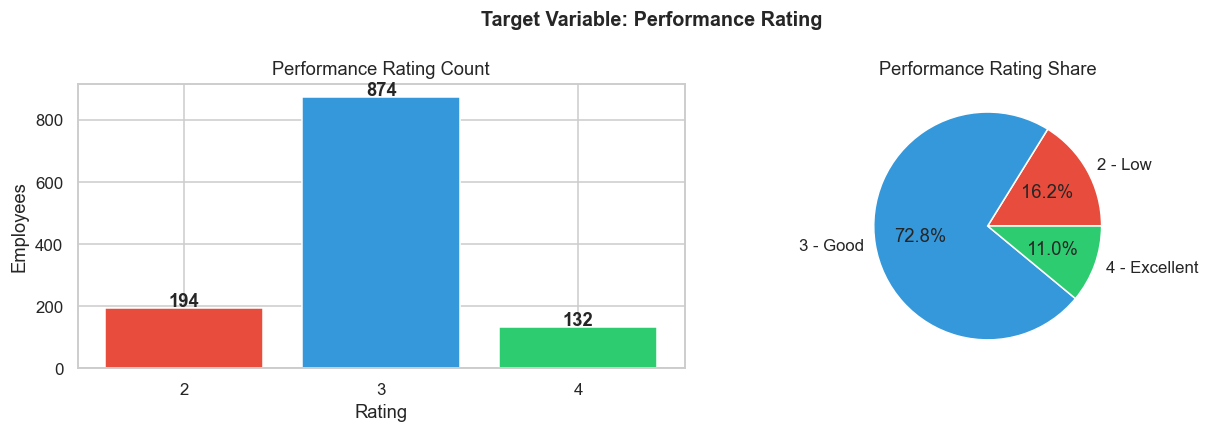

In [2]:
labels = {2: 'Low', 3: 'Good', 4: 'Excellent'}
counts = df['PerformanceRating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(counts.index.astype(str), counts.values,
            color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Performance Rating Count')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Employees')

# Pie chart
axes[1].pie(counts.values, labels=[f'{r} - {labels[r]}' for r in counts.index],
            autopct='%1.1f%%', colors=['#e74c3c','#3498db','#2ecc71'],
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Performance Rating Share')

plt.suptitle('Target Variable: Performance Rating', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3 — Department-wise Performance

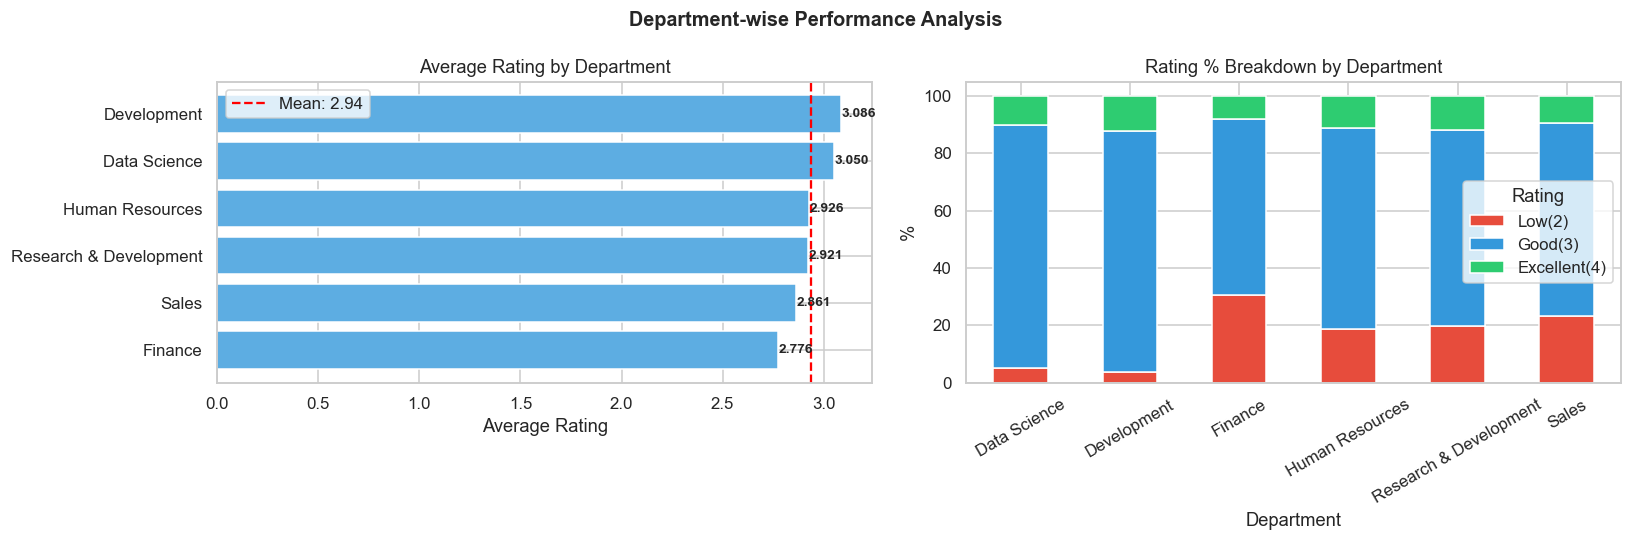

EmpDepartment
Finance                   2.775510
Sales                     2.860590
Research & Development    2.921283
Human Resources           2.925926
Data Science              3.050000
Development               3.085873
Name: PerformanceRating, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average rating per department
avg = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values()
axes[0].barh(avg.index, avg.values, color='#5dade2', edgecolor='white')
axes[0].axvline(avg.mean(), color='red', linestyle='--', label=f'Mean: {avg.mean():.2f}')
for i, v in enumerate(avg.values):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontweight='bold', fontsize=9)
axes[0].set_title('Average Rating by Department')
axes[0].set_xlabel('Average Rating')
axes[0].legend()

# % breakdown per department
pct = df.groupby('EmpDepartment')['PerformanceRating'].value_counts(normalize=True).unstack() * 100
pct.plot(kind='bar', stacked=True, ax=axes[1],
         color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1].set_title('Rating % Breakdown by Department')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Rating', labels=['Low(2)','Good(3)','Excellent(4)'])

plt.suptitle('Department-wise Performance Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values())

## Step 4 — Key Features vs Performance

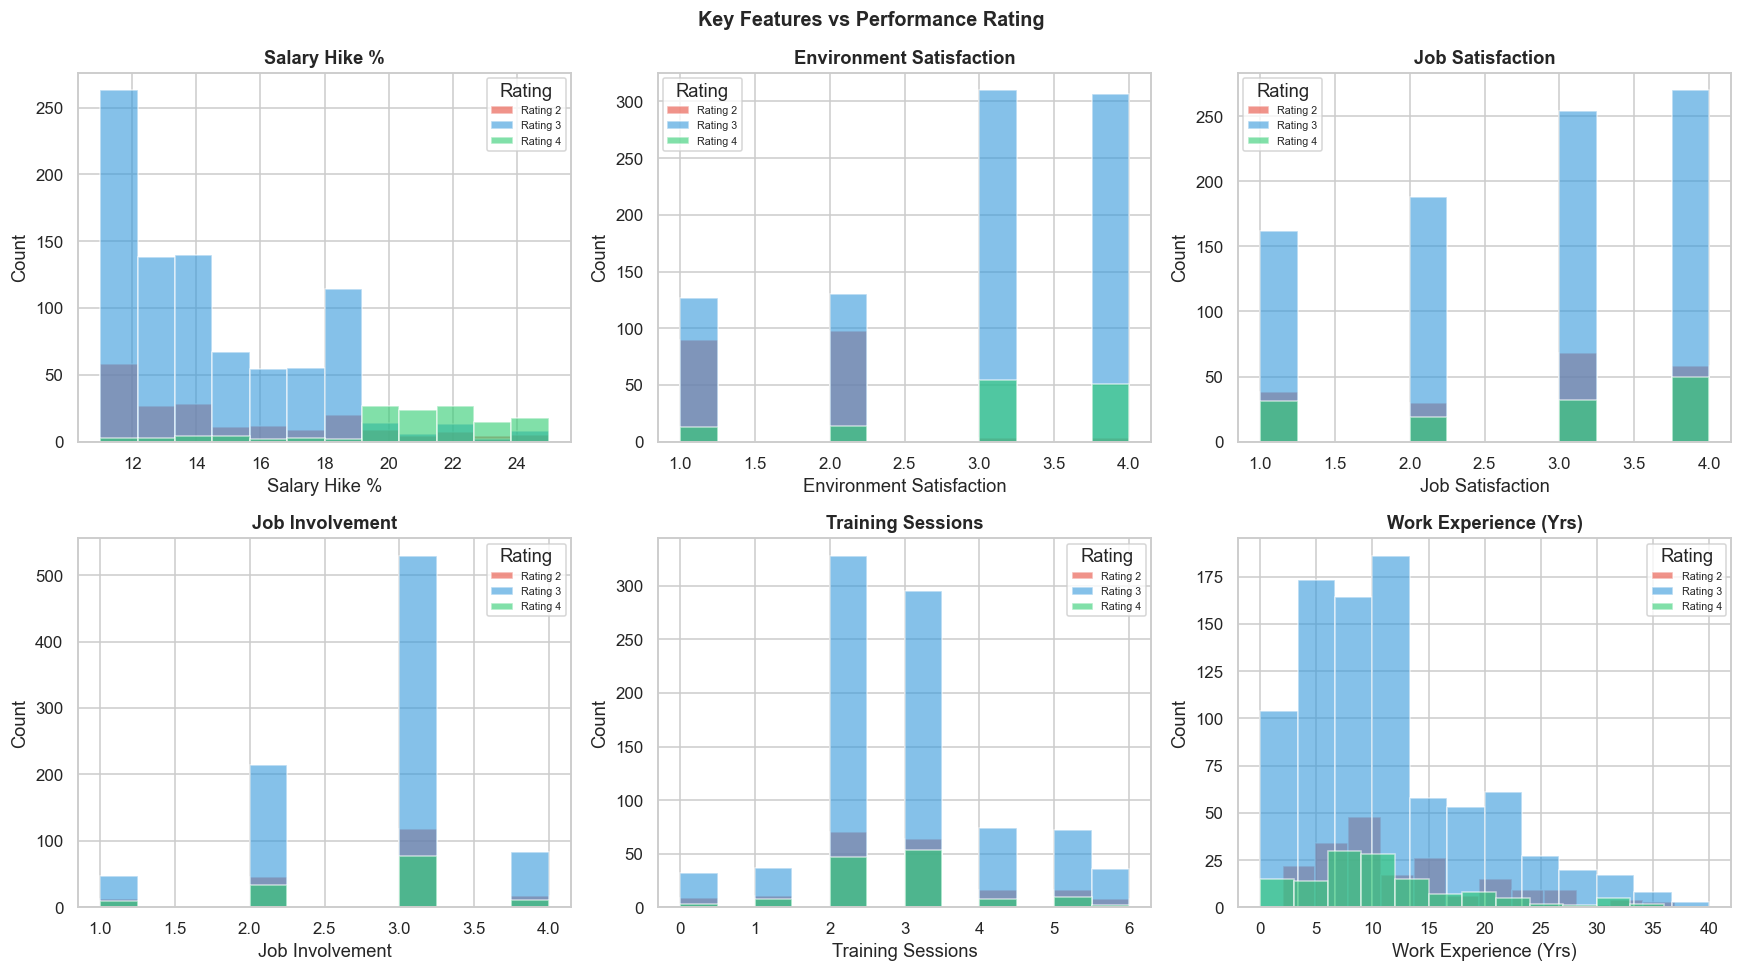

In [4]:
features = [
    ('EmpLastSalaryHikePercent',    'Salary Hike %'),
    ('EmpEnvironmentSatisfaction',  'Environment Satisfaction'),
    ('EmpJobSatisfaction',          'Job Satisfaction'),
    ('EmpJobInvolvement',           'Job Involvement'),
    ('TrainingTimesLastYear',       'Training Sessions'),
    ('TotalWorkExperienceInYears',  'Work Experience (Yrs)'),
]
palette = {2:'#e74c3c', 3:'#3498db', 4:'#2ecc71'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, label) in zip(axes.flatten(), features):
    for rating, grp in df.groupby('PerformanceRating'):
        ax.hist(grp[col], alpha=0.6, label=f'Rating {rating}',
                color=palette[rating], bins=12, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(title='Rating', fontsize=7)

plt.suptitle('Key Features vs Performance Rating', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 — Overtime & Attrition Impact

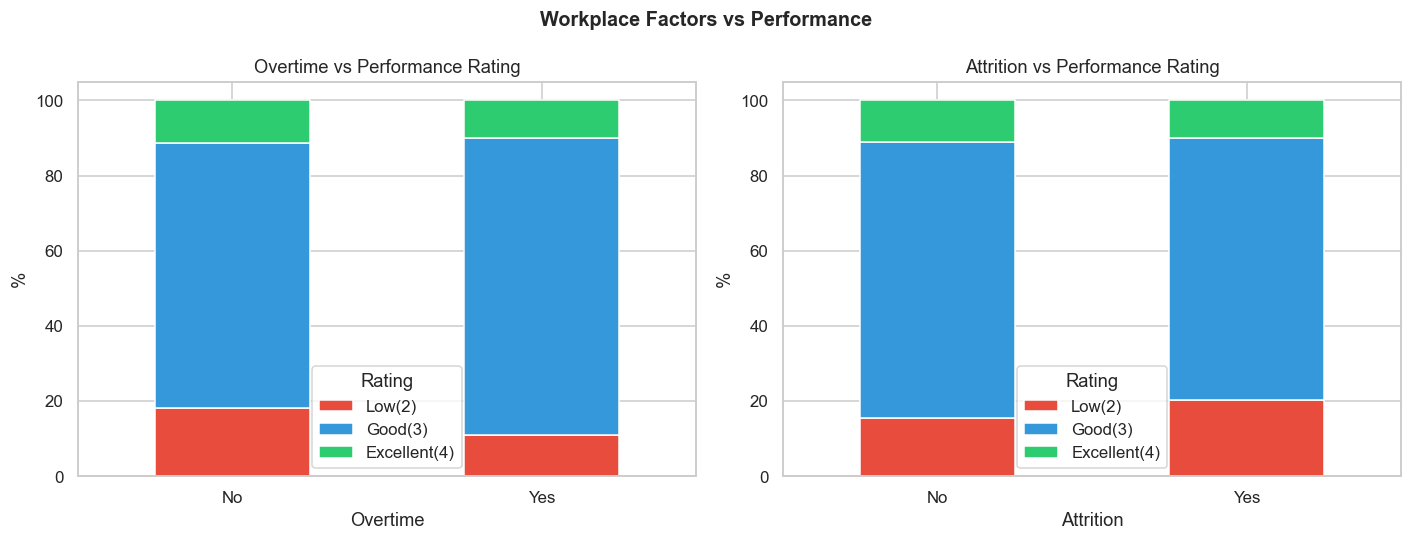

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(axes,
                          ['OverTime',      'Attrition'],
                          ['Overtime',      'Attrition']):
    grp = df.groupby([col,'PerformanceRating']).size().unstack(fill_value=0)
    grp.div(grp.sum(axis=1), axis=0).mul(100).plot(
        kind='bar', stacked=True, ax=ax,
        color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
    ax.set_title(f'{label} vs Performance Rating')
    ax.set_xlabel(label)
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Rating', labels=['Low(2)','Good(3)','Excellent(4)'])

plt.suptitle('Workplace Factors vs Performance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 — Correlation Heatmap

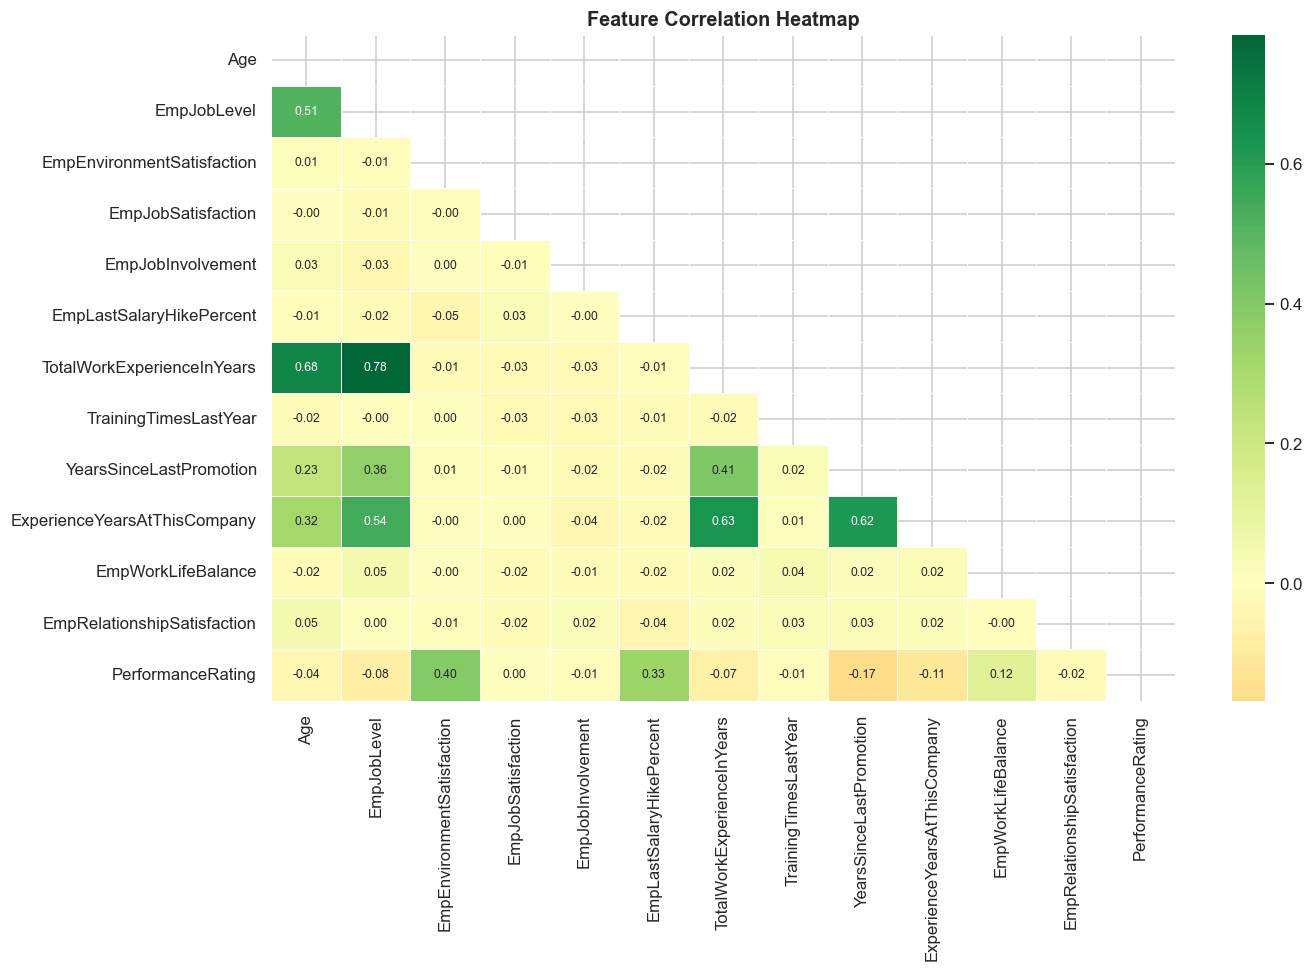


Top correlations with PerformanceRating:
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
YearsSinceLastPromotion         0.167629
EmpWorkLifeBalance              0.124429
ExperienceYearsAtThisCompany    0.111645
EmpJobLevel                     0.076632
TotalWorkExperienceInYears      0.068141
Age                             0.040164
Name: PerformanceRating, dtype: float64


In [6]:
# Use only original numeric columns (before one-hot expansion)
num_cols = [
    'Age', 'EmpJobLevel', 'EmpEnvironmentSatisfaction', 'EmpJobSatisfaction',
    'EmpJobInvolvement', 'EmpLastSalaryHikePercent', 'TotalWorkExperienceInYears',
    'TrainingTimesLastYear', 'YearsSinceLastPromotion', 'ExperienceYearsAtThisCompany',
    'EmpWorkLifeBalance', 'EmpRelationshipSatisfaction', 'PerformanceRating'
]
corr = df_num[num_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, center=0,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop correlations with PerformanceRating:")
print(corr['PerformanceRating'].drop('PerformanceRating').abs().sort_values(ascending=False).head(8))

## Step 7 — EDA Summary

In [7]:
print("=" * 55)
print("  EDA SUMMARY")
print("=" * 55)

print("\n1. Target Distribution:")
for r, cnt in df['PerformanceRating'].value_counts().sort_index().items():
    print(f"   Rating {r}: {cnt} employees ({cnt/len(df)*100:.1f}%)")

print("\n2. Department Avg Ratings (low to high):")
for d, v in df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values().items():
    print(f"   {d:35s}: {v:.3f}")

print("\n3. Key Insights:")
print("   - Salary hike % is the strongest predictor")
print("   - High env & job satisfaction = better performance")
print("   - Finance and Sales have most low performers")
print("   - Development and Data Science are top departments")
print("   - More training sessions → better performance")

  EDA SUMMARY

1. Target Distribution:
   Rating 2: 194 employees (16.2%)
   Rating 3: 874 employees (72.8%)
   Rating 4: 132 employees (11.0%)

2. Department Avg Ratings (low to high):
   Finance                            : 2.776
   Sales                              : 2.861
   Research & Development             : 2.921
   Human Resources                    : 2.926
   Data Science                       : 3.050
   Development                        : 3.086

3. Key Insights:
   - Salary hike % is the strongest predictor
   - High env & job satisfaction = better performance
   - Finance and Sales have most low performers
   - Development and Data Science are top departments
   - More training sessions → better performance
